### Initialize spark on local

<b><i>Pre-requisites</i></b><br>
<ol>
    <li>Download and install jdk-11 from openjdk-11</li>
    <li>Download and extract apache spark v3.5.6</li>
    <li>Copy paste winutils.exe and hadoop.dll from requirements folder in repo for hadoop v3.4.0 into <b><i>C:/hadoop/bin</i></b></li>
    <li>Create environment variables <b>JAVA_HOME, SPARK_HOME and HADOOP_HOME</b>.
    <ul>
        <li> JAVA_HOME = "path to java folder containing bin folder."</li>
        <li> SPARK_HOME = "path to spark folder containing bin folder where we have extracted"</li>
        <li> HADOOP_HOME = "path to hadoop folder containing bin folder where we have copied winutils.exe and hadoop.dll"</li>
    </ul>
    </li>
    <li>Add path of java, spark and hadoop bin folder to <b>PATH</b> system variable</li>
    <li>In the terminal run <b><i>pip install pyspark==3.5.6 findspark jupyter</i></b></li>
    <li>Close and reopen terminal window.</li>
</ol>

In [1]:
import findspark
import os
# os.environ["SPARK_HOME"] = "C:/Users/chinmay.chaudhari/Documents/Softwares/spark-3.5.6-bin-hadoop3/spark-3.5.6-bin-hadoop3"
# os.environ["JAVA_HOME"] = "C:/Program Files/Eclipse Adoptium/jdk-11.0.28.6-hotspot"
# os.environ["HADOOP_HOME"] = "C:/hadoop"
findspark.init()

In [2]:
curr_dir = os.getcwd()
print(curr_dir)

C:\Users\chinmay.chaudhari\Documents\Project Docs\Holman Assessment\Code assessment


In [3]:
import pyspark
print(pyspark.__version__)

3.5.6


In [4]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("AssessmentApp").master("local[*]").getOrCreate()
print(spark.version)

3.5.6


In [5]:
# data = [["Chinmay",10],["Jash",10],["Ria",10]]
# df = spark.createDataFrame(data,schema="name string, marks int")
# df.show()

### Stage raw data

#### Ingest Olympics data

In [6]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

In [7]:
olympics_data_path = f"{curr_dir}/datasets/raw/olympics"
olympics_schema = StructType([StructField("name_of_country",StringType(), False)
                              ,StructField("gold_medals_won",StringType(), False)
                              ,StructField("silver_medals_won",StringType(), False)
                              ,StructField("bronze_medals_won",StringType(), False)
                              ,StructField("total_medals_won",StringType(), False)])
olympics_df = spark.read.option("sep",",").option("pathGlobFilter","*csv").schema(olympics_schema).csv(olympics_data_path)\
                .filter("gold_medals_won<>'Gold'")\
                .withColumn("gold_medals_won", col("gold_medals_won").cast("int"))\
                .withColumn("silver_medals_won", col("silver_medals_won").cast("int"))\
                .withColumn("bronze_medals_won", col("bronze_medals_won").cast("int"))\
                .withColumn("total_medals_won", col("total_medals_won").cast("int"))
olympics_df.show(10)

+---------------+---------------+-----------------+-----------------+----------------+
|name_of_country|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|
+---------------+---------------+-----------------+-----------------+----------------+
|            USA|             39|               41|               33|             113|
|            CHN|             38|               32|               19|              89|
|            JPN|             27|               14|               17|              58|
|            GBR|             22|               20|               22|              64|
|            ROC|             20|               28|               23|              71|
|            AUS|             17|                7|               22|              46|
|            NED|             10|               12|               14|              36|
|            FRA|             10|               12|               11|              33|
|            GER|             10|          

In [8]:
# Add olympic event name from the CSV file name
olympics_df = olympics_df.withColumn("file_split", reverse(split(input_file_name(),"/"))[0])\
    .withColumn("filename_split", split(col("file_split"),"%20"))\
    .withColumn("filename_split", when(array_size(col("filename_split"))==1,split(col("file_split"),"_")).otherwise(col("filename_split")))\
    .withColumn("olympics_year",col("filename_split")[1].cast("string"))\
    .withColumn("olympics_location",col("filename_split")[0])\
    .drop("filename_split","file_split")
olympics_df.show(10, truncate=False)

+---------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+
|name_of_country|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|olympics_year|olympics_location|
+---------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+
|USA            |39             |41               |33               |113             |2020         |Tokyo            |
|CHN            |38             |32               |19               |89              |2020         |Tokyo            |
|JPN            |27             |14               |17               |58              |2020         |Tokyo            |
|GBR            |22             |20               |22               |64              |2020         |Tokyo            |
|ROC            |20             |28               |23               |71              |2020         |Tokyo            |
|AUS            |17             |7              

In [9]:
olympics_df.printSchema()

root
 |-- name_of_country: string (nullable = true)
 |-- gold_medals_won: integer (nullable = true)
 |-- silver_medals_won: integer (nullable = true)
 |-- bronze_medals_won: integer (nullable = true)
 |-- total_medals_won: integer (nullable = true)
 |-- olympics_year: string (nullable = true)
 |-- olympics_location: string (nullable = true)



In [10]:
olympics_stage_data_path = f"{curr_dir}/datasets/stage/olympics/"
olympics_df.coalesce(1).write.mode("overwrite").parquet(olympics_stage_data_path)

#### Ingest Countries data

In [11]:
countries_data_path = f"{curr_dir}/datasets/raw/countries/countries of the world.csv"
countries_df = spark.read.option("sep",",").option("header","true").option("inferSchema","true").csv(countries_data_path)\
            .select(trim(col("Country")).alias("country_name"))
countries_df.show()

+-----------------+
|     country_name|
+-----------------+
|      Afghanistan|
|          Albania|
|          Algeria|
|   American Samoa|
|          Andorra|
|           Angola|
|         Anguilla|
|Antigua & Barbuda|
|        Argentina|
|          Armenia|
|            Aruba|
|        Australia|
|          Austria|
|       Azerbaijan|
|     Bahamas, The|
|          Bahrain|
|       Bangladesh|
|         Barbados|
|          Belarus|
|          Belgium|
+-----------------+
only showing top 20 rows



In [12]:
country_cd_data_path = f"{curr_dir}/datasets/raw/countries/country_code_to_country_name_mapping.csv"
country_cd_schema = StructType([StructField("country_name",StringType(), False)
                              ,StructField("country_code",StringType(), False)])
country_cd_df = spark.read.option("sep",",").option("header","false").schema(country_cd_schema).csv(country_cd_data_path)
country_cd_df.show()

+-----------------+------------+
|     country_name|country_code|
+-----------------+------------+
|      Afghanistan|         AFG|
|          Albania|         ALB|
|          Algeria|         ALG|
|          Andorra|         AND|
|           Angola|         ANG|
|Antigua & Barbuda|         ANT|
|        Argentina|         ARG|
|          Armenia|         ARM|
|            Aruba|         ARU|
|   American Samoa|         ASA|
|        Australia|         AUS|
|          Austria|         AUT|
|       Azerbaijan|         AZE|
|     Bahamas, The|         BAH|
|       Bangladesh|         BAN|
|         Barbados|         BAR|
|          Burundi|         BDI|
|          Belgium|         BEL|
|            Benin|         BEN|
|          Bermuda|         BER|
+-----------------+------------+
only showing top 20 rows



In [13]:
countries_joined_df = countries_df.alias("src").join(country_cd_df.alias("lkp"),countries_df["country_name"]==country_cd_df["country_name"],"inner")\
            .select("src.*","lkp.country_code")
countries_joined_df.show()
# countries_joined_df.filter("lkp.country_code is NULL").select("src.name_of_country").distinct().show()

+-----------------+------------+
|     country_name|country_code|
+-----------------+------------+
|      Afghanistan|         AFG|
|          Albania|         ALB|
|          Algeria|         ALG|
|          Andorra|         AND|
|           Angola|         ANG|
|Antigua & Barbuda|         ANT|
|        Argentina|         ARG|
|          Armenia|         ARM|
|            Aruba|         ARU|
|   American Samoa|         ASA|
|        Australia|         AUS|
|          Austria|         AUT|
|       Azerbaijan|         AZE|
|     Bahamas, The|         BAH|
|       Bangladesh|         BAN|
|         Barbados|         BAR|
|          Burundi|         BDI|
|          Belgium|         BEL|
|            Benin|         BEN|
|          Bermuda|         BER|
+-----------------+------------+
only showing top 20 rows



In [14]:
countries_stage_data_path = f"{curr_dir}/datasets/stage/countries/"
countries_joined_df.coalesce(1).write.mode("overwrite").parquet(countries_stage_data_path)

### Merge staged data

In [15]:
olympics_df1 = spark.read.parquet(olympics_stage_data_path)
olympics_df1.show()

+---------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+
|name_of_country|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|olympics_year|olympics_location|
+---------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+
|            USA|             39|               41|               33|             113|         2020|            Tokyo|
|            CHN|             38|               32|               19|              89|         2020|            Tokyo|
|            JPN|             27|               14|               17|              58|         2020|            Tokyo|
|            GBR|             22|               20|               22|              64|         2020|            Tokyo|
|            ROC|             20|               28|               23|              71|         2020|            Tokyo|
|            AUS|             17|               

In [16]:
countries_df1 = spark.read.parquet(countries_stage_data_path)
countries_df1.show()

+-----------------+------------+
|     country_name|country_code|
+-----------------+------------+
|      Afghanistan|         AFG|
|          Albania|         ALB|
|          Algeria|         ALG|
|          Andorra|         AND|
|           Angola|         ANG|
|Antigua & Barbuda|         ANT|
|        Argentina|         ARG|
|          Armenia|         ARM|
|            Aruba|         ARU|
|   American Samoa|         ASA|
|        Australia|         AUS|
|          Austria|         AUT|
|       Azerbaijan|         AZE|
|     Bahamas, The|         BAH|
|       Bangladesh|         BAN|
|         Barbados|         BAR|
|          Burundi|         BDI|
|          Belgium|         BEL|
|            Benin|         BEN|
|          Bermuda|         BER|
+-----------------+------------+
only showing top 20 rows



In [17]:
# Check if for any country code we have duplicate entries
countries_df1.groupBy("country_code").agg(count("country_name").alias("cnt_of_countries")).filter("cnt_of_countries>1").show()

+------------+----------------+
|country_code|cnt_of_countries|
+------------+----------------+
|    DR Congo|               2|
+------------+----------------+



In [18]:
# Check for above duplicate code in olympics data 
dup_cnt = olympics_df1.filter("name_of_country='DR Congo'").count()
if dup_cnt>0:
    raise Exception("Duplicate country codes found.")
else:
    print("No duplicate country codes. Okay to proceed.")

No duplicate country codes. Okay to proceed.


In [19]:
joined_df = olympics_df1.alias("src").join(countries_df1.alias("lkp"),olympics_df1['name_of_country']==countries_df1['country_code'],"left_outer")\
            .select("src.*","lkp.country_name")\
            .withColumnRenamed("name_of_country","country_code")
joined_df.show(10)

+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+--------------------+
|country_code|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|olympics_year|olympics_location|        country_name|
+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+--------------------+
|         USA|             39|               41|               33|             113|         2020|            Tokyo|       United States|
|         CHN|             38|               32|               19|              89|         2020|            Tokyo|               China|
|         JPN|             27|               14|               17|              58|         2020|            Tokyo|               Japan|
|         GBR|             22|               20|               22|              64|         2020|            Tokyo|      United Kingdom|
|         ROC|             20|           

You might see that there are some country code which are not mapped correctly thats because there are some country codes which are not actually
country codes but Olympics Code for participants from a group. So we will fill these code manually using mapping dictionary.

In [20]:
# Check if any of the country names are NULL
joined_df.filter("country_name is NULL").show()

+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+------------+
|country_code|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|olympics_year|olympics_location|country_name|
+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+------------+
|         ROC|             20|               28|               23|              71|         2020|            Tokyo|        NULL|
|         KOS|              2|                0|                0|               2|         2020|            Tokyo|        NULL|
|         AIN|              1|                3|                1|               5|         2024|            Paris|        NULL|
|         KOS|              0|                1|                1|               2|         2024|            Paris|        NULL|
|         ROT|              0|                0|                1|               1|         2024|

In [21]:
mapping_dict = {'SCG':'Serbia and Montenegro'
                , 'OAR':'Olympic Athletes from Russia'
                , 'KOS':'Kosovo', 'AIN':'Individual Neutral Athletes'
                , 'IOA':'Individual Olympic Athletes'
                , 'ROT':'Refugee Olympic Team'
                , 'MNE':'Montenegro'
                , 'YUG':'Yugoslavia'
                , 'ROC':'Russian Olympic Committee'}
map_missing_cd = udf(lambda x: mapping_dict.get(x))

In [22]:
joined_df = joined_df.withColumn("country_name", when(col("country_name").isNotNull(),col("country_name")).otherwise(map_missing_cd(col("country_code"))))
joined_df.filter("country_name is NULL").show()
# Now all the olympics country codes are mapped to their respective name/description

+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+------------+
|country_code|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|olympics_year|olympics_location|country_name|
+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+------------+
+------------+---------------+-----------------+-----------------+----------------+-------------+-----------------+------------+



In [23]:
final_df = joined_df.drop("country_code")\
    .select("olympics_year","olympics_location","country_name","gold_medals_won","silver_medals_won","bronze_medals_won","total_medals_won")
final_df.show()

+-------------+-----------------+--------------------+---------------+-----------------+-----------------+----------------+
|olympics_year|olympics_location|        country_name|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|
+-------------+-----------------+--------------------+---------------+-----------------+-----------------+----------------+
|         2020|            Tokyo|       United States|             39|               41|               33|             113|
|         2020|            Tokyo|               China|             38|               32|               19|              89|
|         2020|            Tokyo|               Japan|             27|               14|               17|              58|
|         2020|            Tokyo|      United Kingdom|             22|               20|               22|              64|
|         2020|            Tokyo|Russian Olympic C...|             20|               28|               23|              71|
|       

In [24]:
# Analyze the final data before writing
final_df.groupBy("country_name").agg(sum("total_medals_won").alias("total_medals_won"),sum("gold_medals_won").alias("total_gold_medals_won"))\
    .orderBy(desc("total_medals_won")).show()

+--------------------+----------------+---------------------+
|        country_name|total_medals_won|total_gold_medals_won|
+--------------------+----------------+---------------------+
|       United States|             957|                  356|
|               China|             588|                  241|
|             Germany|             551|                  184|
|              Russia|             483|                  170|
|              France|             370|                  111|
|      United Kingdom|             353|                  118|
|               Italy|             332|                   98|
|           Australia|             331|                   99|
|              Canada|             314|                   93|
|               Japan|             313|                  105|
|Netherlands Antilles|             276|                   98|
|              Norway|             267|                  106|
|        Korea, South|             264|                   96|
|       

In [25]:
olympics_publish_data_path = f"{curr_dir}/datasets/publish/olympics/"
final_df.coalesce(1).write.mode("overwrite").parquet(olympics_publish_data_path)

### Visualize published data

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [27]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql import Window

In [28]:
olympics_publish_data_path = f"{curr_dir}/datasets/publish/olympics/"
n=10 # The number of data points to consider for reporting
published_df = spark.read.parquet(olympics_publish_data_path)
published_df.show()

+-------------+-----------------+--------------------+---------------+-----------------+-----------------+----------------+
|olympics_year|olympics_location|        country_name|gold_medals_won|silver_medals_won|bronze_medals_won|total_medals_won|
+-------------+-----------------+--------------------+---------------+-----------------+-----------------+----------------+
|         2020|            Tokyo|       United States|             39|               41|               33|             113|
|         2020|            Tokyo|               China|             38|               32|               19|              89|
|         2020|            Tokyo|               Japan|             27|               14|               17|              58|
|         2020|            Tokyo|      United Kingdom|             22|               20|               22|              64|
|         2020|            Tokyo|Russian Olympic C...|             20|               28|               23|              71|
|       

In [29]:
pie_chart_pdf = published_df.groupBy("country_name").agg(sum("total_medals_won").alias("total_medals_won"))\
    .orderBy(desc("total_medals_won"))\
    .toPandas()\
    .head(n)
pie_chart_pdf.head(5)

,country_name,total_medals_won
0,United States,957
1,China,588
2,Germany,551
3,Russia,483
4,France,370


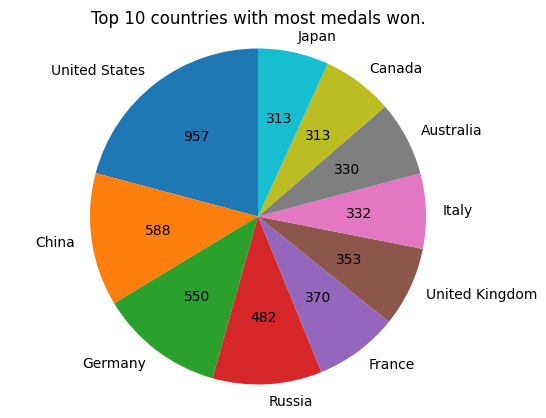

In [30]:
total = np.sum(pie_chart_pdf['total_medals_won'])
plt.pie(
    pie_chart_pdf['total_medals_won'],
    labels=pie_chart_pdf['country_name'],
    autopct=lambda p:f"{int(p*total/100)}",
    startangle=90
)
plt.title(f"Top {n} countries with most medals won.")
plt.axis("equal")
plt.show()

In [31]:
sbar_chart_pdf = published_df.groupBy("country_name").agg(sum("gold_medals_won").alias("gold_medals_won"),sum("silver_medals_won").alias("silver_medals_won"),sum("bronze_medals_won").alias("bronze_medals_won"))\
    .orderBy(desc("gold_medals_won"))\
    .toPandas()\
    .head(n)
sbar_chart_pdf.head(5)

,country_name,gold_medals_won,silver_medals_won,bronze_medals_won
0,United States,356,315,286
1,China,241,192,155
2,Germany,184,188,179
3,Russia,170,151,162
4,United Kingdom,118,113,122


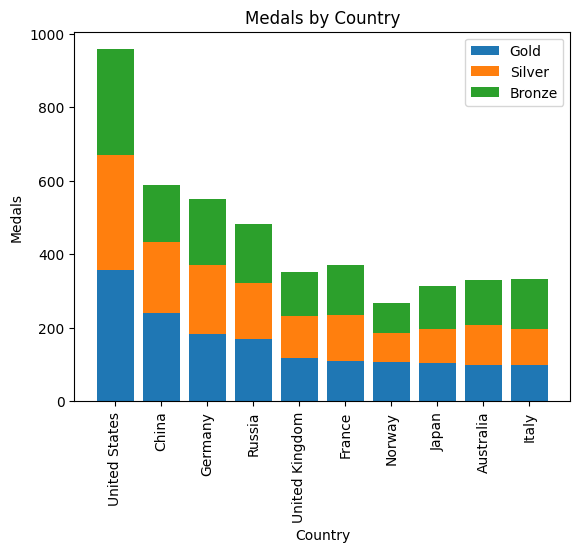

In [32]:
plt.bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['gold_medals_won'], label='Gold')
plt.bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['silver_medals_won'],bottom=sbar_chart_pdf['gold_medals_won'], label='Silver')
plt.bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['bronze_medals_won'],bottom=sbar_chart_pdf['gold_medals_won']+sbar_chart_pdf['silver_medals_won'], label='Bronze')
plt.xticks(rotation='vertical')
plt.xlabel("Country")
plt.ylabel("Medals")
plt.title("Medals by Country")
plt.legend()
plt.show()

In [33]:
window = Window.partitionBy("olympics_year").orderBy(desc("total_medals_won"))
sbar_chart_pdf1 = published_df.groupBy(["olympics_year","country_name"]).agg(sum("total_medals_won").alias("total_medals_won"))\
    .withColumn("rnk", row_number().over(window))\
    .filter("rnk<=5")\
    .drop("rnk")\
    .toPandas()
sbar_chart_pdf1.head(5)

,olympics_year,country_name,total_medals_won
0,1994,Norway,26
1,1994,Germany,24
2,1994,Russia,23
3,1994,Italy,20
4,1994,United States,13


In [34]:
pvt_df = sbar_chart_pdf1.pivot(index='olympics_year', columns='country_name',values='total_medals_won').fillna(0)
pvt_df.head()

country_name,Australia,Austria,Canada,China,France,Germany,Italy,Japan,Netherlands Antilles,Norway,Russia,Russian Olympic Committee,United Kingdom,United States
olympics_year,,,,,,,,,,,,,,
1994,0.0,0.0,0.0,0.0,0.0,24.0,20.0,0.0,0.0,26.0,23.0,0.0,0.0,13.0
1996,41.0,0.0,0.0,50.0,0.0,65.0,0.0,0.0,0.0,0.0,63.0,0.0,0.0,101.0
1998,0.0,17.0,15.0,0.0,0.0,29.0,0.0,0.0,0.0,25.0,18.0,0.0,0.0,0.0
2000,58.0,0.0,0.0,58.0,0.0,56.0,0.0,0.0,0.0,0.0,89.0,0.0,0.0,93.0
2002,0.0,17.0,17.0,0.0,0.0,36.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,34.0


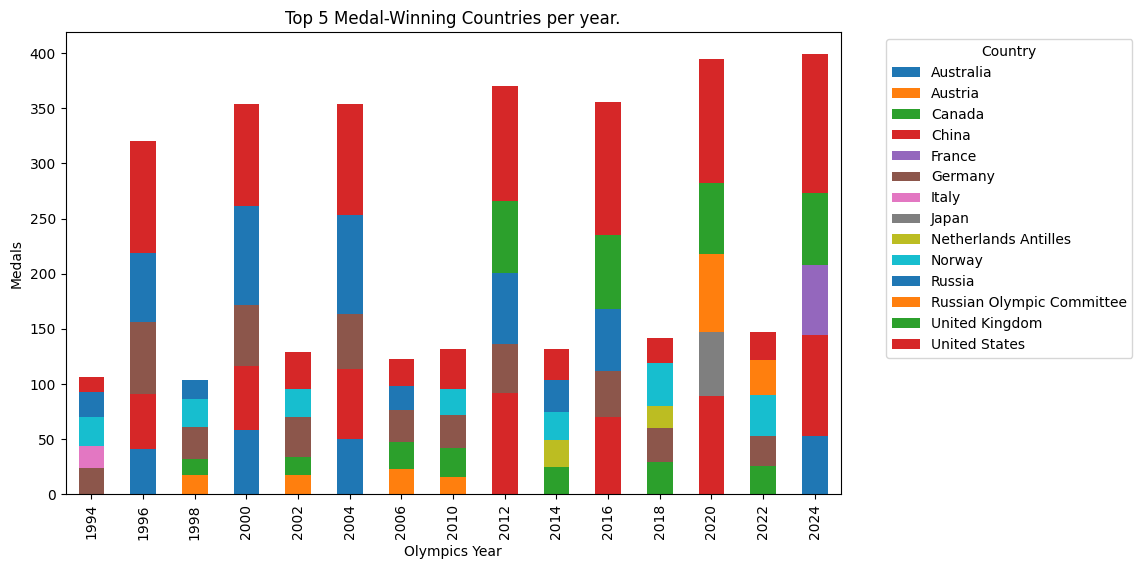

In [35]:
pvt_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title("Top 5 Medal-Winning Countries per year.")
plt.xlabel("Olympics Year")
plt.ylabel("Medals")
plt.legend(title='Country',loc='upper left', bbox_to_anchor=(1.05,1))
plt.xticks(rotation=90)
plt.show()

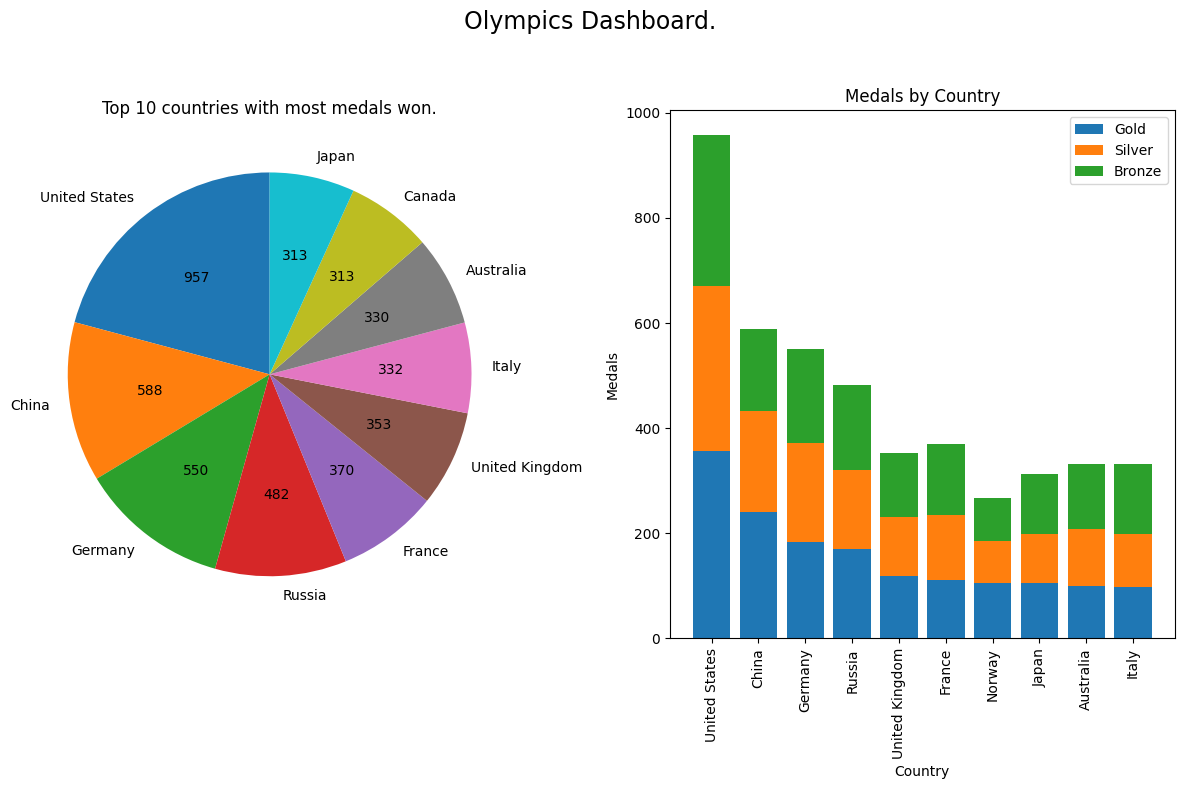

In [36]:
# Dashboard layout using matplotlib
fig, ax = plt.subplots(1,2, figsize=(12,8))
fig.suptitle("Olympics Dashboard.", fontsize=17)

# 1. Pie Chart
total = np.sum(pie_chart_pdf['total_medals_won'])
ax[0].pie(
    pie_chart_pdf['total_medals_won'],
    labels=pie_chart_pdf['country_name'],
    autopct=lambda p:f"{int(p*total/100)}",
    startangle=90
)
ax[0].set_title(f"Top {n} countries with most medals won.")

# Stacked Line Chart
ax[1].bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['gold_medals_won'], label='Gold')
ax[1].bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['silver_medals_won'],bottom=sbar_chart_pdf['gold_medals_won'], label='Silver')
ax[1].bar(sbar_chart_pdf['country_name'], sbar_chart_pdf['bronze_medals_won'],bottom=sbar_chart_pdf['gold_medals_won']+sbar_chart_pdf['silver_medals_won'], label='Bronze')
ax[1].set_xticks(ticks=sbar_chart_pdf['country_name'], labels=sbar_chart_pdf['country_name'], rotation='vertical')
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Medals")
ax[1].set_title("Medals by Country")
ax[1].legend()

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()